In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sales_df = pd.read_csv(r"C:\Users\win 11\Downloads\rossmann-store-sales\train.csv",low_memory=False)
sales_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [3]:
stores_df = pd.read_csv(r"C:\Users\win 11\Downloads\rossmann-store-sales\store.csv")
stores_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [4]:
print("sales data shape:",sales_df.shape)
print("stores data shape:",stores_df.shape)

sales data shape: (1017209, 9)
stores data shape: (1115, 10)


In [5]:
#sales data sample: S Rows
sales_df.sample(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
604681,22,7,2014-01-05,0,0,0,0,0,0
747368,1104,6,2013-08-31,5688,432,1,0,0,0
620829,560,7,2013-12-22,0,0,0,0,0,0
870506,477,7,2013-05-12,0,0,0,0,0,0
350523,87,7,2014-08-31,0,0,0,0,0,0


In [6]:
#store data sample: S Rows
stores_df.sample(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
516,517,a,c,22490.0,NaN,NaN,0,NaN,NaN,NaN
722,723,d,c,5650.0,9.0,2008.0,1,5.0,2013.0,"Feb,May,Aug,Nov"
51,52,d,c,450.0,4.0,2014.0,1,39.0,2010.0,"Jan,Apr,Jul,Oct"
724,725,d,c,17540.0,6.0,2012.0,0,NaN,NaN,NaN
731,732,a,c,35280.0,NaN,NaN,0,NaN,NaN,NaN


In [7]:
# merging sales dataframe and store dataframe
df = pd.merge(sales_df, stores_df, on='Store',how='left')
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [8]:
df.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [10]:
def convert_dtypes(df:pd.DataFrame,col:str, dtype=None, inplace:bool=False):
    try:
        if not dtype:
            print("data-type not defined")
        if col not in df.columns:
            print(f"{col} is not present in the given dataframe. the present columns are:{df.columns}")
        if inplace:
            df[col]=df[col].astype(dtype)
            print("datatype successfully changed....")
        else:
            return df[col].astype(dtype)
    except Exception as e:
        print(f"Got exception while changing dtype: {e}")

#convert_dtypes(df,'Store','int16',inplace=True)
#convert_dtypes(df,'Store','int16',inplace=False)

In [11]:
convert_dtypes(df,'Store','int16',inplace=True)
convert_dtypes(df,'DayOfWeek','int8',inplace=True)
convert_dtypes(df,'Date','datetime64[ns]' ,inplace=True)

datatype successfully changed....
datatype successfully changed....
datatype successfully changed....


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int16         
 1   DayOfWeek                  1017209 non-null  int8          
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [13]:
df[df['CompetitionDistance'].isnull()]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,5,2015-07-31,10052,973,1,1,0,1,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,5,2015-07-31,6306,540,1,1,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,5,2015-07-31,6000,466,1,1,0,0,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"
1405,291,4,2015-07-30,9030,883,1,1,0,1,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
1736,622,4,2015-07-30,5412,406,1,1,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015601,622,3,2013-01-02,4080,451,1,0,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
1015858,879,3,2013-01-02,3077,326,1,0,0,1,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"
1016385,291,2,2013-01-01,0,0,0,0,a,1,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
1016716,622,2,2013-01-01,0,0,0,0,a,1,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN


In [14]:
from typing import Literal
def fill_missing_values(df:pd.DataFrame, col:str, inplace:bool=False,stratagy: Literal ['mean',"median","mode","const"]='mean',const_value=None):
    try:
        #df = df.copy()
        if col not in df.columns:
            print(f"{col} is not present in the given dataframe. the present columns are:{df.columns}")
        if stratagy in ('mean','median','mode','const'):
            if stratagy.lower()=='mean':
                df[col]=df[col].fillna(df[col].mean())
                return df[col]
            elif stratagy.lower()=='median':
                df[col]=df[col].fillna(df[col].median())
                return df[col]
            elif stratagy.lower()=='mode':
                df[col]=df[col].fillna(df[col].mode()[0])
                return df[col]
            elif stratagy.lower()=='const':
                 if not const_value:
                    print("You must provide a constant value.")
                 else:
                    df[col] = df[col].fillna(const_value)
                    return df[col]
                    
            print("missing value successfully filled...")
    except Exception as e:
        print("Got exception while changing dtypes :{e}")

In [15]:
fill_missing_values(df, 'CompetitionDistance', inplace=True).isnull().sum()

np.int64(0)

In [16]:
#dictionary
d = {"Store":"int16",
     "DayOfWeek": "int8",          
     "Date":"datetime64[ns]",
     "Sales":"int16",        
     "Customers":"int8",         
     "Open":"int8",         
     "Promo": "int8",        
     "StateHoliday":"category",       
     "SchoolHoliday":"int8",         
     "StoreType":"category",        
     "Assortment":"category",        
     "CompetitionDistance":"float32",       
     "CompetitionOpenSinceMonth":"Int16",       
     "CompetitionOpenSinceYear":"Int16",       
     "Promo2":"int8",         
     "Promo2SinceWeek":"Int16" ,      
     "Promo2SinceYear":"Int16",       
     "PromoInterval":"string"
}
for key , val in d.items():
     convert_dtypes(df, key, val, inplace=True)


datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....


datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....
datatype successfully changed....


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int16         
 1   DayOfWeek                  1017209 non-null  int8          
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int16         
 4   Customers                  1017209 non-null  int8          
 5   Open                       1017209 non-null  int8          
 6   Promo                      1017209 non-null  int8          
 7   StateHoliday               1017209 non-null  category      
 8   SchoolHoliday              1017209 non-null  int8          
 9   StoreType                  1017209 non-null  category      
 10  Assortment                 1017209 non-null  category      
 11  CompetitionDistance        1017209 no

In [18]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance               0
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

<Axes: >

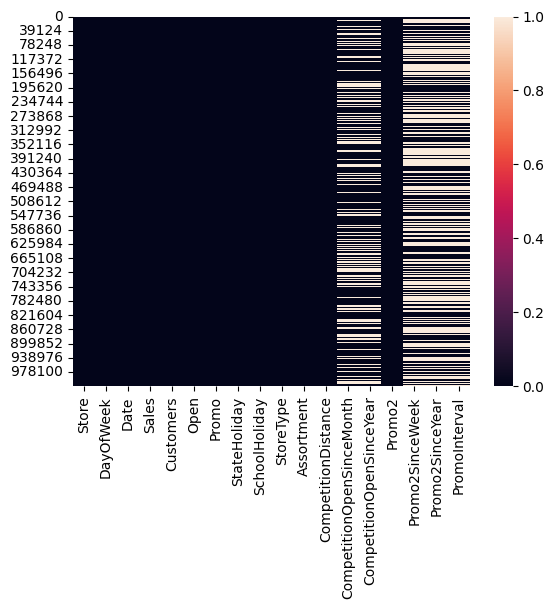

In [19]:
sns.heatmap(df.isnull())

In [20]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,43,1,1,0,1,c,a,1270.0,9,2008,0,<NA>,<NA>,<NA>
1,2,5,2015-07-31,6064,113,1,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,53,1,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,-38,1,1,0,1,c,c,620.0,9,2009,0,<NA>,<NA>,<NA>
4,5,5,2015-07-31,4822,47,1,1,0,1,a,a,29910.0,4,2015,0,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6,2014,1,31,2013,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4,2006,0,<NA>,<NA>,<NA>
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,<NA>,<NA>,0,<NA>,<NA>,<NA>
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,<NA>,<NA>,0,<NA>,<NA>,<NA>


In [21]:
#handle missing values 
df['CompetitionDistance']=df['CompetitionDistance'].fillna(-1) 
df['CompetitionOpenSinceMonth']=df['CompetitionOpenSinceMonth'].fillna(-1)	
fill_missing_values(df,'CompetitionOpenSinceYear',stratagy='const', const_value=-1)
fill_missing_values(df,'Promo2SinceWeek',stratagy='const', const_value=-1)
fill_missing_values(df,'Promo2SinceYear',stratagy='const', const_value=-1)
fill_missing_values(df,'PromoInterval',stratagy='const', const_value='unk')

0                       unk
1           Jan,Apr,Jul,Oct
2           Jan,Apr,Jul,Oct
3                       unk
4                       unk
                 ...       
1017204     Jan,Apr,Jul,Oct
1017205                 unk
1017206                 unk
1017207                 unk
1017208    Mar,Jun,Sept,Dec
Name: PromoInterval, Length: 1017209, dtype: string

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int16         
 1   DayOfWeek                  1017209 non-null  int8          
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int16         
 4   Customers                  1017209 non-null  int8          
 5   Open                       1017209 non-null  int8          
 6   Promo                      1017209 non-null  int8          
 7   StateHoliday               1017209 non-null  category      
 8   SchoolHoliday              1017209 non-null  int8          
 9   StoreType                  1017209 non-null  category      
 10  Assortment                 1017209 non-null  category      
 11  CompetitionDistance        1017209 no

In [23]:
df=df[df['Open']==1].drop(columns='Open')
df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,43,1,0,1,c,a,1270.0,9,2008,0,-1,-1,unk
1,2,5,2015-07-31,6064,113,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,53,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,-38,1,0,1,c,c,620.0,9,2009,0,-1,-1,unk
4,5,5,2015-07-31,4822,47,1,0,1,a,a,29910.0,4,2015,0,-1,-1,unk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,54,0,a,1,b,a,150.0,9,2006,0,-1,-1,unk
1016827,733,2,2013-01-01,10765,73,0,a,1,b,b,860.0,10,1999,0,-1,-1,unk
1016863,769,2,2013-01-01,5035,-32,0,a,1,b,b,840.0,-1,-1,1,48,2012,"Jan,Apr,Jul,Oct"
1017042,948,2,2013-01-01,4491,15,0,a,1,b,b,1430.0,-1,-1,0,-1,-1,unk


In [24]:
df = df[df['Sales']>0].copy()
df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,43,1,0,1,c,a,1270.0,9,2008,0,-1,-1,unk
1,2,5,2015-07-31,6064,113,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,53,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,-38,1,0,1,c,c,620.0,9,2009,0,-1,-1,unk
4,5,5,2015-07-31,4822,47,1,0,1,a,a,29910.0,4,2015,0,-1,-1,unk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,54,0,a,1,b,a,150.0,9,2006,0,-1,-1,unk
1016827,733,2,2013-01-01,10765,73,0,a,1,b,b,860.0,10,1999,0,-1,-1,unk
1016863,769,2,2013-01-01,5035,-32,0,a,1,b,b,840.0,-1,-1,1,48,2012,"Jan,Apr,Jul,Oct"
1017042,948,2,2013-01-01,4491,15,0,a,1,b,b,1430.0,-1,-1,0,-1,-1,unk


In [25]:
#reseting index
df.reset_index(drop=True,inplace=True)
df

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,43,1,0,1,c,a,1270.0,9,2008,0,-1,-1,unk
1,2,5,2015-07-31,6064,113,1,0,1,a,a,570.0,11,2007,1,13,2010,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,53,1,0,1,a,a,14130.0,12,2006,1,14,2011,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,-38,1,0,1,c,c,620.0,9,2009,0,-1,-1,unk
4,5,5,2015-07-31,4822,47,1,0,1,a,a,29910.0,4,2015,0,-1,-1,unk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844290,682,2,2013-01-01,3375,54,0,a,1,b,a,150.0,9,2006,0,-1,-1,unk
844291,733,2,2013-01-01,10765,73,0,a,1,b,b,860.0,10,1999,0,-1,-1,unk
844292,769,2,2013-01-01,5035,-32,0,a,1,b,b,840.0,-1,-1,1,48,2012,"Jan,Apr,Jul,Oct"
844293,948,2,2013-01-01,4491,15,0,a,1,b,b,1430.0,-1,-1,0,-1,-1,unk


In [26]:
#top  10 store by sales
top_10_sales = df.groupby('Store')['Sales'].sum().nlargest(10)

In [27]:
sns.set_theme(palette='magma')

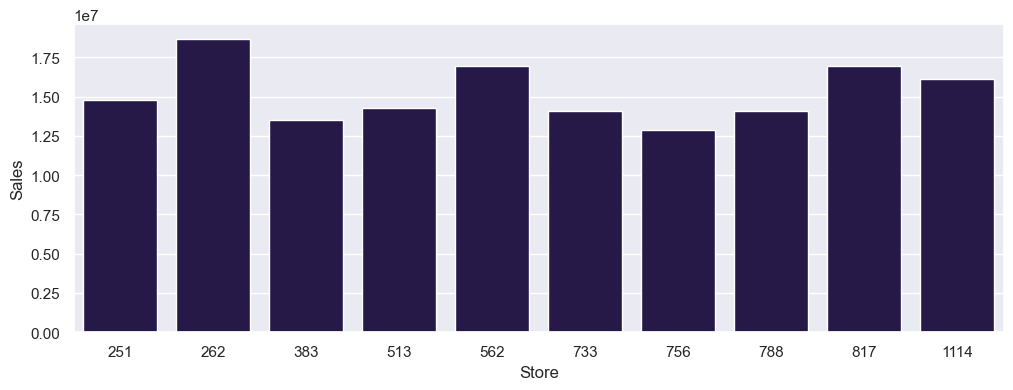

In [28]:
plt.figure(figsize=(12,4))
sns.barplot(top_10_sales)
plt.show()

<Axes: >

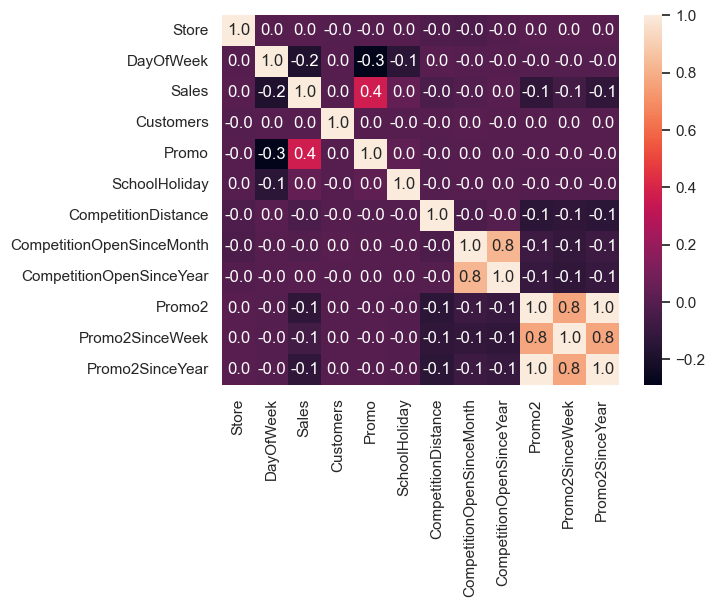

In [29]:
#corr
sns.heatmap(df.select_dtypes('number').corr(),fmt='.1f',annot=True)

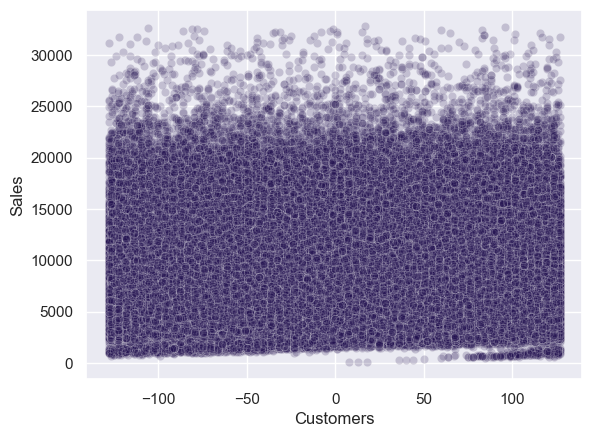

In [30]:
#sales vs customer
plt.Figure(figsize=(12,4))
sns.scatterplot(df,x='Customers', y='Sales',alpha=0.2)
plt.show()

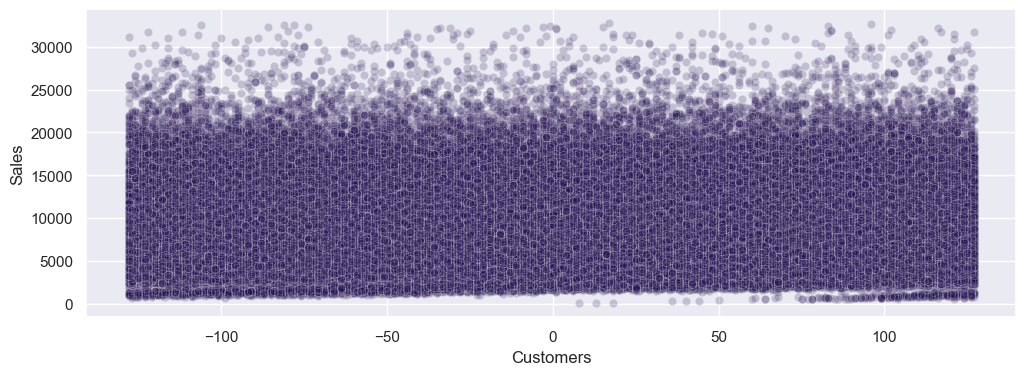

In [31]:
#sales vs customer
plt.figure(figsize=(12,4))
sns.scatterplot(df,x='Customers', y='Sales',alpha=0.2)
plt.show()